#EDA of formula 1 dataset to find out dependencies races results from pit stops.

##The hypothesis is that the more winding the track, the earlier a pit stop must be made due to increased tire degradation.

A comprehensive analysis would also require considering the time gaps to rivals ahead and behind (undercut and overcut strategies) and other characteristics. However, as this is an academic project, the study focuses on the number of pit stops, the lap on which they were performed, the tire types used before and after the pit stop and weather conditions.
Subsequently, the Mann-Whitney test is used to identify statistical differences in the optimal pit stop timing across three track types (street, mixed, and high-speed/straight-heavy).

##First stage: building the ETL pipeline.

In [26]:
!pip install pandas
!pip install numpy
!pip install kaggle
!pip install matplotlib
!pip install seaborn
!pip install scipy

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.3/30.3 MB 13.6 MB/s  0:00:02 eta 0:00:01


In [2]:
import os

!mkdir -p ~/.kaggle

!cp kaggle.json ~/.kaggle/

!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d vanshbatra26/f1-tyre-strategy-engine-datasets

!kaggle datasets download -d meruvakodandasuraj/formula-1-race-intelligence-20102026

!kaggle datasets download -d vanshjasuja16/f1-Strategy-Dataset-Pit-Stop-Prediction

!unzip -o f1-tyre-strategy-engine-datasets.zip

!unzip -o formula-1-race-intelligence-20102026.zip

!unzip -o f1-Strategy-Dataset-Pit-Stop-Prediction.zip


/Users/napoleon/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
Dataset URL: https://www.kaggle.com/datasets/vanshbatra26/f1-tyre-strategy-engine-datasets
License(s): CC-BY-SA-4.0
  0%|                                              | 0.00/4.93M [00:00<?, ?B/s]
100%|█████████████████████████████████████| 4.93M/4.93M [00:00<00:00, 1.99GB/s]
/Users/napoleon/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
Dataset URL: https://www.kaggle.com/datasets/meruvakodandasuraj/formula-1-race-intelligence-20102026
License(s): apache-2.0
  0%|                                             

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

##Second stage: loading datasets

In [3]:
base_url = 'https://raw.githubusercontent.com/muharsyad/formula-one-datasets/main'

In [40]:
#Dataset with information about pit stops. There was an error in the lap count in this dataset: there turned out to be one fewer lap.

pitstops = pd.read_csv(f'{base_url}/pitstops.csv')
pitstops['lap'] = pitstops['lap'] + 1
pitstops = pitstops[pitstops['season'] >= 2023]

pitstops.head()

,season,round,driverId,lap,stop,time,duration
9634,2023,1,gasly,10,1,18:18:56,25.885
9635,2023,1,norris,11,1,18:20:31,32.766
9636,2023,1,tsunoda,11,1,18:20:34,25.267
9637,2023,1,bottas,12,1,18:22:06,25.399
9638,2023,1,albon,12,1,18:22:12,25.054


In [41]:
#Dataset with information about races.

races = pd.read_csv(f'{base_url}/races.csv')

races.head()

,season,round,raceName,circuitId,circuitName,date,time,firstPractice,secondPractice,thirdPractice,qualifying,sprint,url
0,1950,1,British Grand Prix,silverstone,Silverstone Circuit,1950-05-13,NaN,NaN,NaN,NaN,NaN,NaN,http://en.wikipedia.org/wiki/1950_British_Gran...
1,1950,2,Monaco Grand Prix,monaco,Circuit de Monaco,1950-05-21,NaN,NaN,NaN,NaN,NaN,NaN,http://en.wikipedia.org/wiki/1950_Monaco_Grand...
2,1950,3,Indianapolis 500,indianapolis,Indianapolis Motor Speedway,1950-05-30,NaN,NaN,NaN,NaN,NaN,NaN,http://en.wikipedia.org/wiki/1950_Indianapolis...
3,1950,4,Swiss Grand Prix,bremgarten,Circuit Bremgarten,1950-06-04,NaN,NaN,NaN,NaN,NaN,NaN,http://en.wikipedia.org/wiki/1950_Swiss_Grand_...
4,1950,5,Belgian Grand Prix,spa,Circuit de Spa-Francorchamps,1950-06-18,NaN,NaN,NaN,NaN,NaN,NaN,http://en.wikipedia.org/wiki/1950_Belgian_Gran...


In [42]:
#Dataset with information about drivers. In this dataset, driver's names was differ from those listed in the winners' data, so we have modified them.

drivers = pd.read_csv(f'{base_url}/drivers.csv')
drivers.iloc[596,2] = 'Perez'
drivers.iloc[386,2] = 'Hulkenberg'
drivers.iloc[219,2] = 'De Vries'

drivers.head()

,driverId,givenName,familyName,code,permanentNumber,dateOfBirth,nationality,url
0,abate,Carlo,Abate,NaN,NaN,1932-07-10,Italian,http://en.wikipedia.org/wiki/Carlo_Mario_Abate
1,abecassis,George,Abecassis,NaN,NaN,1913-03-21,British,http://en.wikipedia.org/wiki/George_Abecassis
2,acheson,Kenny,Acheson,NaN,NaN,1957-11-27,British,http://en.wikipedia.org/wiki/Kenny_Acheson
3,adams,Philippe,Adams,NaN,NaN,1969-11-19,Belgian,http://en.wikipedia.org/wiki/Philippe_Adams
4,ader,Walt,Ader,NaN,NaN,1913-12-15,American,http://en.wikipedia.org/wiki/Walt_Ader


In [43]:
#Dataset with information about weather in 2023 and 2024. 
#This dataset contains all meteorological measurements taken throughout the day; therefore, we average the values ​​for the day of race.

weather_2023 = pd.read_csv('F1-Tyre-Strategy-Engine/2023/weather_2023_cleaned.csv')
weather_2023['season'] = 2023
weather_2024 = pd.read_csv('F1-Tyre-Strategy-Engine/2024/cleaned_weather_2024.csv')
weather_2024['season'] = 2024
weather = pd.concat([weather_2023, weather_2024], ignore_index=True)
weather = weather.groupby(['EventName', 'season']).agg({
    'AirTemp': 'mean',
    'Pressure': 'mean',
    'Humidity': 'mean',
    'Rainfall': 'any',
    'WindDirection': 'mean',
    'WindSpeed': 'mean'
}).reset_index()
weather.head()

,EventName,season,AirTemp,Pressure,Humidity,Rainfall,WindDirection,WindSpeed
0,Abu Dhabi Grand Prix,2023,27.521130,1013.157741,57.033473,False,271.108787,1.863180
1,Abu Dhabi Grand Prix,2024,26.768243,1017.426351,51.445946,False,137.033784,1.900676
2,Australian Grand Prix,2023,16.506422,1017.096147,59.238532,True,140.801835,1.236881
3,Australian Grand Prix,2024,19.443133,1022.765236,53.652361,True,145.725322,1.328326
4,Austrian Grand Prix,2023,24.963975,932.710248,44.850932,True,131.000000,1.049379


In [44]:
#Dataset with information about compound before and after pit stops.

compound = pd.read_csv('f1_strategy_dataset_v4.csv')
compound = compound[(compound['Year'] >=2023) & (compound['Year'] <=2024)]
compound.head()

,Driver,LapNumber,Compound,Stint,TyreLife,Position,LapTime (s),Race,Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change
0,ALB,1,MEDIUM,1,2.0,17,100.625,Abu Dhabi Grand Prix,2023,0.000,0.000,0,0,0.017241,0.117647,0.0
1,ALB,2,MEDIUM,1,3.0,18,93.560,Abu Dhabi Grand Prix,2023,-7.065,-7.065,0,0,0.034483,0.176471,-1.0
2,ALB,3,MEDIUM,1,4.0,18,91.768,Abu Dhabi Grand Prix,2023,-1.792,-8.857,0,0,0.051724,0.235294,0.0
3,ALB,4,MEDIUM,1,5.0,18,91.591,Abu Dhabi Grand Prix,2023,-0.177,-9.034,0,0,0.068966,0.294118,0.0
4,ALB,5,MEDIUM,1,6.0,18,91.422,Abu Dhabi Grand Prix,2023,-0.169,-9.203,0,0,0.086207,0.352941,0.0


In [45]:
#Dataset with information about circuits. In this dataset, the names of the circuits and countries differ from those listed in the winners' data, so we have modified them.

circuits_type = pd.read_csv('circuits.csv')

circuits_type.iloc[2,1] = 'Albert Park Grand Prix Circuit'
circuits_type.iloc[3,1] = 'Suzuka Circuit'
circuits_type.iloc[14,1] = 'Circuit Park Zandvoort'
circuits_type.iloc[15,1] = 'Autodromo Nazionale di Monza'
circuits_type.iloc[19,1] = 'Autódromo Hermanos Rodríguez'
circuits_type.iloc[20,1] = 'Autódromo José Carlos Pace'
circuits_type.iloc[21,1] = 'Las Vegas Strip Street Circuit'

circuits_type.iloc[23,2] = 'Abu Dhabi'
circuits_type.iloc[18,2] = 'United States'
circuits_type.iloc[21,2] = 'Las Vegas'
circuits_type.iloc[5,2] = 'Miami'
circuits_type.iloc[11,2] = 'Great Britain'

circuits_type.head()

,circuit_id,circuit_name,country,city,laps,lap_km,type,altitude_m,direction
0,bahrain,Bahrain International Circuit,Bahrain,Sakhir,57,5.412,Permanent,7,Clockwise
1,jeddah,Jeddah Corniche Circuit,Saudi Arabia,Jeddah,50,6.174,Street,5,Clockwise
2,albert_park,Albert Park Grand Prix Circuit,Australia,Melbourne,58,5.278,Street/Park,10,Clockwise
3,suzuka,Suzuka Circuit,Japan,Suzuka,53,5.807,Permanent,42,Mixed
4,shanghai,Shanghai International Circuit,China,Shanghai,56,5.451,Permanent,5,Clockwise


In [46]:
#Dataset with information about winners in races.

dop_url = 'https://raw.githubusercontent.com/toUpperCase78/formula1-datasets/master'

win_2023 = pd.read_csv(f'{dop_url}/Formula1_2023season_raceResults.csv')
win_2023['season'] = 2023

win_2024 = pd.read_csv(f'{dop_url}/Formula1_2024season_raceResults.csv')
win_2024['season'] = 2024

win_table = pd.concat([win_2023, win_2024], ignore_index=True)

win_table.head()

,Track,Position,No,Driver,Team,Starting Grid,Laps,Time/Retired,Points,Set Fastest Lap,Fastest Lap Time,season
0,Bahrain,1,1,Max Verstappen,Red Bull Racing Honda RBPT,1,57,1:33:56.736,25,No,1:36.236,2023
1,Bahrain,2,11,Sergio Perez,Red Bull Racing Honda RBPT,2,57,+11.987,18,No,1:36.344,2023
2,Bahrain,3,14,Fernando Alonso,Aston Martin Aramco Mercedes,5,57,+38.637,15,No,1:36.156,2023
3,Bahrain,4,55,Carlos Sainz,Ferrari,4,57,+48.052,12,No,1:37.130,2023
4,Bahrain,5,44,Lewis Hamilton,Mercedes,7,57,+50.977,10,No,1:36.546,2023


##Third stage: combining all datasets into a single one containing all the information necessary for analysis.

In [47]:
#Joining datasets pitstops and races into merged_pits dataset.

merged_pits = pd.merge(pitstops[['season', 'round', 'lap', 'stop', 'driverId']], races[['season', 'round', 'raceName', 'circuitName']], on=['season', 'round'], how='left')

merged_pits.head()

,season,round,lap,stop,driverId,raceName,circuitName
0,2023,1,10,1,gasly,Bahrain Grand Prix,Bahrain International Circuit
1,2023,1,11,1,norris,Bahrain Grand Prix,Bahrain International Circuit
2,2023,1,11,1,tsunoda,Bahrain Grand Prix,Bahrain International Circuit
3,2023,1,12,1,bottas,Bahrain Grand Prix,Bahrain International Circuit
4,2023,1,12,1,albon,Bahrain Grand Prix,Bahrain International Circuit


In [48]:
#Joining datasets merged_pits and drivers. Adding a new column containing the drivers' full names. Removing unnecessary columns.

drivers['driverId'] = drivers['driverId'].astype(str)
merged_pits['driverId'] = merged_pits['driverId'].astype(str)
merged_pits = pd.merge(merged_pits, drivers[['driverId', 'code', 'givenName', 'familyName']], on='driverId', how='left')

merged_pits['driver'] = merged_pits['givenName'] + ' ' + merged_pits['familyName']

merged_pits = merged_pits.drop(columns=['givenName', 'familyName', 'driverId'])

merged_pits.head()

,season,round,lap,stop,raceName,circuitName,code,driver
0,2023,1,10,1,Bahrain Grand Prix,Bahrain International Circuit,GAS,Pierre Gasly
1,2023,1,11,1,Bahrain Grand Prix,Bahrain International Circuit,NOR,Lando Norris
2,2023,1,11,1,Bahrain Grand Prix,Bahrain International Circuit,TSU,Yuki Tsunoda
3,2023,1,12,1,Bahrain Grand Prix,Bahrain International Circuit,BOT,Valtteri Bottas
4,2023,1,12,1,Bahrain Grand Prix,Bahrain International Circuit,ALB,Alexander Albon


In [49]:
#Joining datasets merged_pits and circuits_tipe. Removing unnecessary columns.

merged_pits = merged_pits.merge(circuits_type[['circuit_name', 'type', 'country']], left_on=['circuitName'], right_on=['circuit_name'], how='left')

merged_pits = merged_pits.drop(columns=['circuit_name'])

merged_pits.loc[
    (merged_pits['circuitName'] == 'Autodromo Enzo e Dino Ferrari') & 
    (merged_pits['season'] == 2024), 
    'country'
] = 'Emilia Romagna'

merged_pits.head()

,season,round,lap,stop,raceName,circuitName,code,driver,type,country
0,2023,1,10,1,Bahrain Grand Prix,Bahrain International Circuit,GAS,Pierre Gasly,Permanent,Bahrain
1,2023,1,11,1,Bahrain Grand Prix,Bahrain International Circuit,NOR,Lando Norris,Permanent,Bahrain
2,2023,1,11,1,Bahrain Grand Prix,Bahrain International Circuit,TSU,Yuki Tsunoda,Permanent,Bahrain
3,2023,1,12,1,Bahrain Grand Prix,Bahrain International Circuit,BOT,Valtteri Bottas,Permanent,Bahrain
4,2023,1,12,1,Bahrain Grand Prix,Bahrain International Circuit,ALB,Alexander Albon,Permanent,Bahrain


In [50]:
#Joining datasets merged_pits and compound. Removing unnecessary columns.

merged_pits = merged_pits.merge(compound[['Year', 'Driver', 'LapNumber', 'Compound', 'Cumulative_Degradation', 'RaceProgress', 'Race']], left_on=['lap', 'season', 'code', 'raceName'], right_on=['LapNumber', 'Year', 'Driver', 'Race'], how='left')

merged_pits = merged_pits.drop(columns=['Year', 'LapNumber', 'Driver', 'Race'])

merged_pits.head()

,season,round,lap,stop,raceName,circuitName,code,driver,type,country,Compound,Cumulative_Degradation,RaceProgress
0,2023,1,10,1,Bahrain Grand Prix,Bahrain International Circuit,GAS,Pierre Gasly,Permanent,Bahrain,HARD,0.0,0.175439
1,2023,1,11,1,Bahrain Grand Prix,Bahrain International Circuit,NOR,Lando Norris,Permanent,Bahrain,HARD,0.0,0.200000
2,2023,1,11,1,Bahrain Grand Prix,Bahrain International Circuit,TSU,Yuki Tsunoda,Permanent,Bahrain,HARD,0.0,0.192982
3,2023,1,12,1,Bahrain Grand Prix,Bahrain International Circuit,BOT,Valtteri Bottas,Permanent,Bahrain,HARD,0.0,0.210526
4,2023,1,12,1,Bahrain Grand Prix,Bahrain International Circuit,ALB,Alexander Albon,Permanent,Bahrain,SOFT,0.0,0.210526


In [51]:
#Joining datasets merged_pits and weather. Removing unnecessary columns.

merged_pits = merged_pits.merge(weather[['season', 'AirTemp', 'Humidity', 'Pressure', 'Rainfall', 'WindDirection', 'WindSpeed', 'EventName']], left_on=['raceName', 'season'], right_on=['EventName', 'season'], how='left')

merged_pits = merged_pits.drop(columns=['EventName'])

merged_pits.head()

,season,round,lap,stop,raceName,circuitName,code,driver,type,country,Compound,Cumulative_Degradation,RaceProgress,AirTemp,Humidity,Pressure,Rainfall,WindDirection,WindSpeed
0,2023,1,10,1,Bahrain Grand Prix,Bahrain International Circuit,GAS,Pierre Gasly,Permanent,Bahrain,HARD,0.0,0.175439,26.036008,20.041096,1017.386888,False,235.90998,1.231507
1,2023,1,11,1,Bahrain Grand Prix,Bahrain International Circuit,NOR,Lando Norris,Permanent,Bahrain,HARD,0.0,0.200000,26.036008,20.041096,1017.386888,False,235.90998,1.231507
2,2023,1,11,1,Bahrain Grand Prix,Bahrain International Circuit,TSU,Yuki Tsunoda,Permanent,Bahrain,HARD,0.0,0.192982,26.036008,20.041096,1017.386888,False,235.90998,1.231507
3,2023,1,12,1,Bahrain Grand Prix,Bahrain International Circuit,BOT,Valtteri Bottas,Permanent,Bahrain,HARD,0.0,0.210526,26.036008,20.041096,1017.386888,False,235.90998,1.231507
4,2023,1,12,1,Bahrain Grand Prix,Bahrain International Circuit,ALB,Alexander Albon,Permanent,Bahrain,SOFT,0.0,0.210526,26.036008,20.041096,1017.386888,False,235.90998,1.231507


In [52]:
#Joining datasets merged_pits and win_table. Removing unnecessary columns.

merged_pits = merged_pits.merge(win_table, left_on=['season', 'country', 'driver'], right_on=['season', 'Track', 'Driver'], how='left')

merged_pits = merged_pits.drop(columns=['Track', 'Driver'])

merged_pits.head()

,season,round,lap,stop,raceName,circuitName,code,driver,type,country,...,WindSpeed,Position,No,Team,Starting Grid,Laps,Time/Retired,Points,Set Fastest Lap,Fastest Lap Time
0,2023,1,10,1,Bahrain Grand Prix,Bahrain International Circuit,GAS,Pierre Gasly,Permanent,Bahrain,...,1.231507,9,10,Alpine Renault,20,57,+73.753,2,No,1:35.068
1,2023,1,11,1,Bahrain Grand Prix,Bahrain International Circuit,NOR,Lando Norris,Permanent,Bahrain,...,1.231507,17,4,McLaren Mercedes,11,55,+2 laps,0,No,1:35.822
2,2023,1,11,1,Bahrain Grand Prix,Bahrain International Circuit,TSU,Yuki Tsunoda,Permanent,Bahrain,...,1.231507,11,22,AlphaTauri Honda RBPT,14,57,+90.870,0,No,1:36.637
3,2023,1,12,1,Bahrain Grand Prix,Bahrain International Circuit,BOT,Valtteri Bottas,Permanent,Bahrain,...,1.231507,8,77,Alfa Romeo Ferrari,12,57,+72.647,4,No,1:37.379
4,2023,1,12,1,Bahrain Grand Prix,Bahrain International Circuit,ALB,Alexander Albon,Permanent,Bahrain,...,1.231507,10,23,Williams Mercedes,15,57,+89.774,1,No,1:37.144


##Fourth stage: selection of training and test sets

In [53]:
#Splitting the final dataset into two tables: one for training data and one for testing data. Data from 2023 is used for training, while data from 2024 is used for testing.

train_data = merged_pits[merged_pits['season'] == 2023].copy()

test_data = merged_pits[merged_pits['season'] >= 2024].copy()

In [54]:
train_data.head()

,season,round,lap,stop,raceName,circuitName,code,driver,type,country,...,WindSpeed,Position,No,Team,Starting Grid,Laps,Time/Retired,Points,Set Fastest Lap,Fastest Lap Time
0,2023,1,10,1,Bahrain Grand Prix,Bahrain International Circuit,GAS,Pierre Gasly,Permanent,Bahrain,...,1.231507,9,10,Alpine Renault,20,57,+73.753,2,No,1:35.068
1,2023,1,11,1,Bahrain Grand Prix,Bahrain International Circuit,NOR,Lando Norris,Permanent,Bahrain,...,1.231507,17,4,McLaren Mercedes,11,55,+2 laps,0,No,1:35.822
2,2023,1,11,1,Bahrain Grand Prix,Bahrain International Circuit,TSU,Yuki Tsunoda,Permanent,Bahrain,...,1.231507,11,22,AlphaTauri Honda RBPT,14,57,+90.870,0,No,1:36.637
3,2023,1,12,1,Bahrain Grand Prix,Bahrain International Circuit,BOT,Valtteri Bottas,Permanent,Bahrain,...,1.231507,8,77,Alfa Romeo Ferrari,12,57,+72.647,4,No,1:37.379
4,2023,1,12,1,Bahrain Grand Prix,Bahrain International Circuit,ALB,Alexander Albon,Permanent,Bahrain,...,1.231507,10,23,Williams Mercedes,15,57,+89.774,1,No,1:37.144


In [55]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 912 entries, 0 to 911
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   season                  912 non-null    int64  
 1   round                   912 non-null    int64  
 2   lap                     912 non-null    int64  
 3   stop                    912 non-null    int64  
 4   raceName                912 non-null    object 
 5   circuitName             912 non-null    object 
 6   code                    912 non-null    object 
 7   driver                  912 non-null    object 
 8   type                    912 non-null    object 
 9   country                 912 non-null    object 
 10  Compound                736 non-null    object 
 11  Cumulative_Degradation  736 non-null    float64
 12  RaceProgress            736 non-null    float64
 13  AirTemp                 912 non-null    float64
 14  Humidity                912 non-null    float64

In [56]:
train_data.loc[train_data['Compound'].isna(), 'Compound'] = train_data['Compound'].mode()[0]

train_data.loc[train_data['Cumulative_Degradation'].isna(), 'Cumulative_Degradation'] = train_data['Cumulative_Degradation'].mean()

train_data.loc[train_data['RaceProgress'].isna(), 'RaceProgress'] = train_data['RaceProgress'].mean()

train_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 912 entries, 0 to 911
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   season                  912 non-null    int64  
 1   round                   912 non-null    int64  
 2   lap                     912 non-null    int64  
 3   stop                    912 non-null    int64  
 4   raceName                912 non-null    object 
 5   circuitName             912 non-null    object 
 6   code                    912 non-null    object 
 7   driver                  912 non-null    object 
 8   type                    912 non-null    object 
 9   country                 912 non-null    object 
 10  Compound                912 non-null    object 
 11  Cumulative_Degradation  912 non-null    float64
 12  RaceProgress            912 non-null    float64
 13  AirTemp                 912 non-null    float64
 14  Humidity                912 non-null    float64

In [57]:
test_data.head()

,season,round,lap,stop,raceName,circuitName,code,driver,type,country,...,WindSpeed,Position,No,Team,Starting Grid,Laps,Time/Retired,Points,Set Fastest Lap,Fastest Lap Time
912,2024,1,2,1,Bahrain Grand Prix,Bahrain International Circuit,HUL,Nico Hulkenberg,Permanent,Bahrain,...,2.018542,16,27,Haas Ferrari,10,56,+1 lap,0,No,1:34.834
913,2024,1,10,1,Bahrain Grand Prix,Bahrain International Circuit,ZHO,Guanyu Zhou,Permanent,Bahrain,...,2.018542,11,24,Kick Sauber Ferrari,17,56,+1 lap,0,No,1:35.458
914,2024,1,10,1,Bahrain Grand Prix,Bahrain International Circuit,STR,Lance Stroll,Permanent,Bahrain,...,2.018542,10,18,Aston Martin Aramco Mercedes,12,57,+93.216,1,No,1:35.632
915,2024,1,11,1,Bahrain Grand Prix,Bahrain International Circuit,OCO,Esteban Ocon,Permanent,Bahrain,...,2.018542,17,31,Alpine Renault,19,56,+1 lap,0,No,1:36.226
916,2024,1,11,1,Bahrain Grand Prix,Bahrain International Circuit,SAR,Logan Sargeant,Permanent,Bahrain,...,2.018542,20,2,Williams Mercedes,18,55,+2 laps,0,No,1:34.735


In [58]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 825 entries, 912 to 1736
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   season                  825 non-null    int64  
 1   round                   825 non-null    int64  
 2   lap                     825 non-null    int64  
 3   stop                    825 non-null    int64  
 4   raceName                825 non-null    object 
 5   circuitName             825 non-null    object 
 6   code                    825 non-null    object 
 7   driver                  825 non-null    object 
 8   type                    825 non-null    object 
 9   country                 825 non-null    object 
 10  Compound                739 non-null    object 
 11  Cumulative_Degradation  739 non-null    float64
 12  RaceProgress            739 non-null    float64
 13  AirTemp                 825 non-null    float64
 14  Humidity                825 non-null    floa

In [59]:
test_data.loc[test_data['Compound'].isna(), 'Compound'] = test_data['Compound'].mode()[0]

test_data.loc[test_data['Cumulative_Degradation'].isna(), 'Cumulative_Degradation'] = test_data['Cumulative_Degradation'].mean()

test_data.loc[test_data['RaceProgress'].isna(), 'RaceProgress'] = test_data['RaceProgress'].mean()

test_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 825 entries, 912 to 1736
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   season                  825 non-null    int64  
 1   round                   825 non-null    int64  
 2   lap                     825 non-null    int64  
 3   stop                    825 non-null    int64  
 4   raceName                825 non-null    object 
 5   circuitName             825 non-null    object 
 6   code                    825 non-null    object 
 7   driver                  825 non-null    object 
 8   type                    825 non-null    object 
 9   country                 825 non-null    object 
 10  Compound                825 non-null    object 
 11  Cumulative_Degradation  825 non-null    float64
 12  RaceProgress            825 non-null    float64
 13  AirTemp                 825 non-null    float64
 14  Humidity                825 non-null    floa

#Exploratory Data Analysis (EDA). Data visualization for analysis. Hypothesis testing.

##Formulating hypotheses

##The main Hypothesis: The pit stop strategy in Formula 1 (the lap on which the pit stop is performed, the type of tires installed) depends statistically significantly on the track type and weather conditions.

Sub-hypothesis 1: Track Type Effect on Pit Stop Lap (Mann-Whitney U test)
    H₀₁: The distribution of the pit stop lap does not differ between track types (Street, Street/Park, Mixed, Permanent).
	H₁₁: On street circuits (Street, Street/Park), pit stops are performed statistically significantly earlier than on high-speed circuits (Permanent).

Sub-hypothesis 2: Track Type Effect on Tire Degradation (Mann-Whitney U test)
    H₀₂: The cumulative tire degradation (Cumulative_Degradation) at the time of the pit stop does not differ between track types.
	H₁₂: On street circuits, tire degradation at the time of the pit stop is statistically significantly higher than on high-speed circuits.

Sub-hypothesis 3: Weather Effect on Tire Compound Selection (Chi-square test of independence)
    H₀₃: The distribution of tire compounds (Compound: SOFT/MEDIUM/HARD) does not depend on the presence of rainfall (Rainfall).
	H₁₃: In rainy conditions, softer tire compounds (SOFT) are used statistically significantly more often, while in dry conditions, harder compounds (HARD) are preferred.

Sub-hypothesis 4: Tire Compound Effect on Final Position (Kruskal-Wallis test)
    H₀₄: The driver’s final position (Position) does not depend on the type of tires installed (Compound).
	H₁₄: The tire selection strategy statistically significantly affects the driver’s final position.

Sub-hypothesis 5: Air Temperature Effect on Degradation (Spearman’s rank correlation coefficient)
    H₀₅: The cumulative tire degradation (Cumulative_Degradation) does not correlate with air temperature (AirTemp).
	H₁₅: There is a statistically significant positive correlation between air temperature and tire degradation.

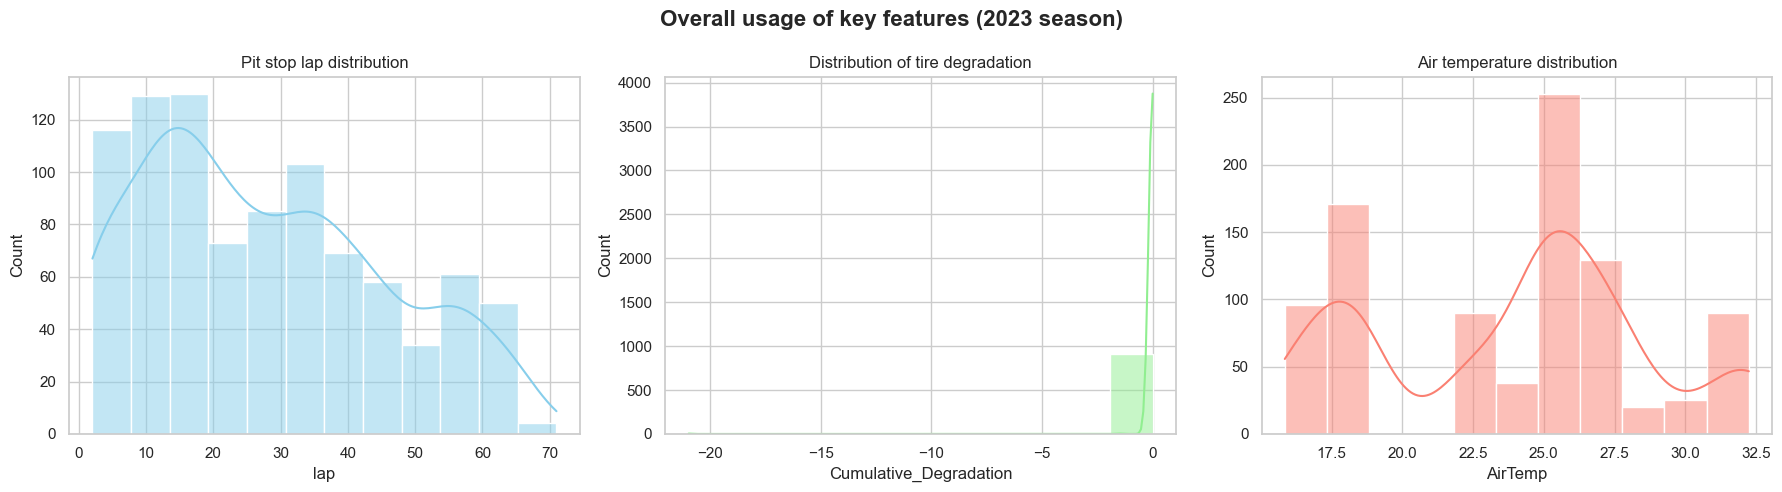

In [75]:
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Overall usage of key features (2023 season)', fontsize=16, fontweight='bold')

sns.histplot(train_data['lap'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Pit stop lap distribution')

sns.histplot(train_data['Cumulative_Degradation'].dropna(), kde=True, ax=axes[1], color='lightgreen')
axes[1].set_title('Distribution of tire degradation')

sns.histplot(train_data['AirTemp'], kde=True, ax=axes[2], color='salmon')
axes[2].set_title('Air temperature distribution')

plt.tight_layout()
plt.show()

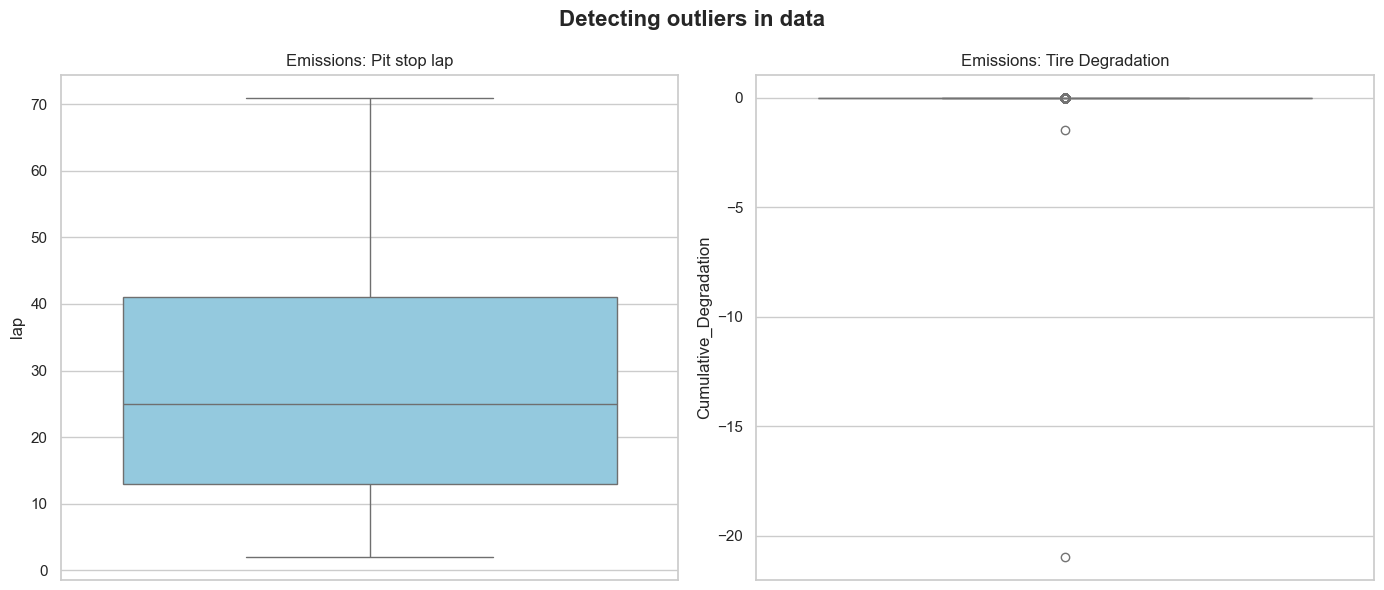

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Detecting outliers in data', fontsize=16, fontweight='bold')

sns.boxplot(data=train_data, y='lap', ax=axes[0], color='skyblue')
axes[0].set_title('Emissions: Pit stop lap')

sns.boxplot(data=train_data, y='Cumulative_Degradation', ax=axes[1], color='lightgreen')
axes[1].set_title('Emissions: Tire Degradation')

plt.tight_layout()
plt.show()

Analysis of the histograms showed that the distribution of pit-stop laps is right-skewed rather than normal. A boxplot revealed the presence of outliers (e.g., pit stops on very late laps, >50), justifying the choice of non-parametric tests (Mann-Whitney) over parametric ones (t-test).

/var/folders/tm/r6qc9lf90wb73mg9xq86rr9h0000gn/T/ipykernel_45615/2052931640.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_data, x='type', y='lap', palette='Set2', order=track_order)


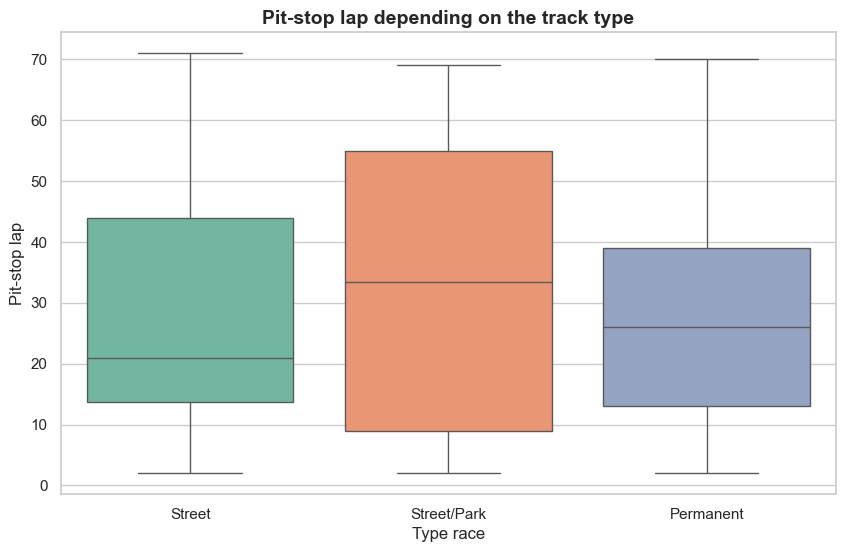

In [79]:
plt.figure(figsize=(10, 6))
track_order = ['Street', 'Street/Park', 'Permanent']
sns.boxplot(data=train_data, x='type', y='lap', palette='Set2', order=track_order)
plt.title('Pit-stop lap depending on the track type', fontsize=14, fontweight='bold')
plt.xlabel('Type race')
plt.ylabel('Pit-stop lap')
plt.show()

In [72]:
street_laps = train_data[train_data['type'] == 'Street']['lap'].dropna()
permanent_laps = train_data[train_data['type'] == 'Permanent']['lap'].dropna()

stat, p_value = stats.mannwhitneyu(street_laps, permanent_laps, alternative='two-sided')

print(f'Median for lap on Street: {street_laps.median():.1f}')
print(f'Median for lap on Permanent: {permanent_laps.median():.1f}')
print(f'U-statistic: {stat:.2f}, p-value: {p_value:.4f}')

if p_value < 0.05:
    print('p < 0.05. The null hypothesis is rejected. There are statistically significant differences: pit stops are made earlier on street circuits.')
else:
    print('p >= 0.05. There are no statistically significant differences in pit stop duration between these types of tracks.')

Median for lap on Street: 21.0
Median for lap on Permanent: 26.0
U-statistic: 45068.00, p-value: 0.7726
p >= 0.05. There are no statistically significant differences in pit stop duration between these types of tracks.


/var/folders/tm/r6qc9lf90wb73mg9xq86rr9h0000gn/T/ipykernel_45615/3139134671.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_data, x='type', y='Cumulative_Degradation', palette='Set2', order=track_order)


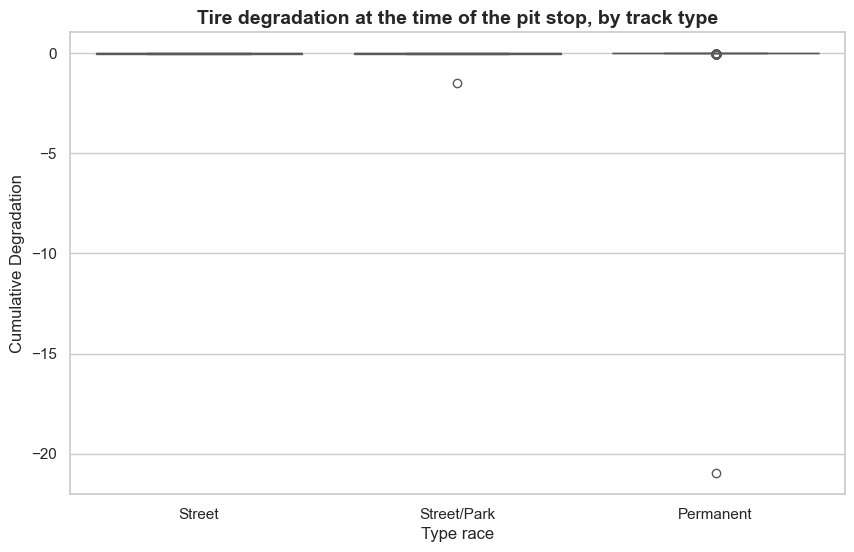

In [73]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=train_data, x='type', y='Cumulative_Degradation', palette='Set2', order=track_order)
plt.title('Tire degradation at the time of the pit stop, by track type', fontsize=14, fontweight='bold')
plt.xlabel('Type race')
plt.ylabel('Cumulative Degradation')
plt.show()

In [93]:
street_deg = train_data[train_data['type'] == 'Street']['Cumulative_Degradation'].dropna()
permanent_deg = train_data[train_data['type'] == 'Permanent']['Cumulative_Degradation'].dropna()

stat, p_value = stats.mannwhitneyu(street_deg, permanent_deg, alternative='two-sided')

print(f'Median for lap on Street: {street_deg.median():.2f}')
print(f'Median for lap on Permanent: {permanent_deg.median():.2f}')
print(f'U-statistic: {stat:.2f}, p-value: {p_value:.4f}')

if p_value < 0.05:
    print('p < 0.05. The null hypothesis is rejected. The level of degradation differs in a statistically significant manner depending on the type of route.')
else:
    print('p >= 0.05. No statistically significant differences in degradation were found.')

Median for lap on Street: 0.00
Median for lap on Permanent: 0.00
U-statistic: 36804.00, p-value: 0.0000
p < 0.05. The null hypothesis is rejected. The level of degradation differs in a statistically significant manner depending on the type of route.


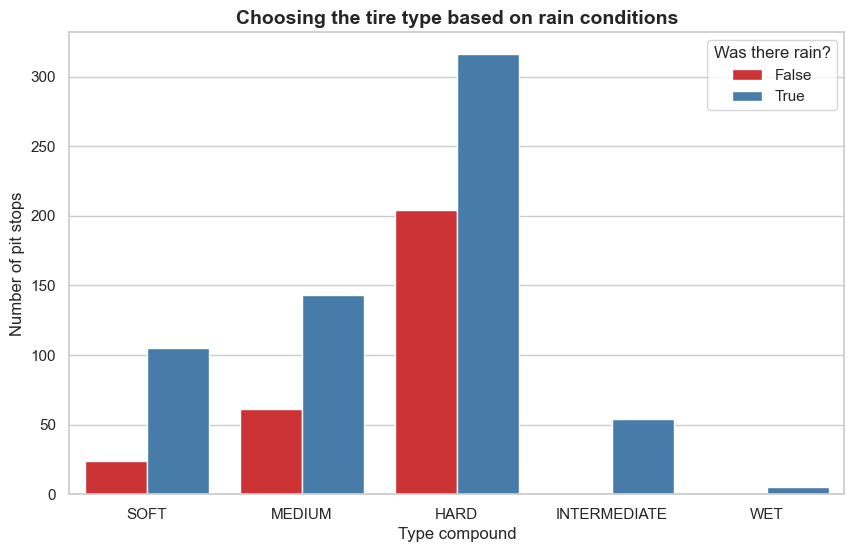

In [94]:
plt.figure(figsize=(10, 6))
sns.countplot(data=train_data, x='Compound', hue='Rainfall', palette='Set1', order=['SOFT', 'MEDIUM', 'HARD', 'INTERMEDIATE', 'WET'])
plt.title('Choosing the tire type based on rain conditions', fontsize=14, fontweight='bold')
plt.xlabel('Type compound')
plt.ylabel('Number of pit stops')
plt.legend(title='Was there rain?')
plt.show()

In [95]:
contingency_table = pd.crosstab(train_data['Rainfall'], train_data['Compound'])
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print('Contingency table:')
print(contingency_table)
print(f'Chi-square statistic: {chi2:.2f}, p-value: {p_value:.4f}')

if p_value < 0.05:
    print('p < 0.05. The null hypothesis is rejected. The choice of tire type depends on weather conditions (rain) in a statistically significant manner.')
else:
    print('p >= 0.05. There is no statistically significant relationship between rain and the choice of tire compound in this sample.')

Contingency table:
Compound  HARD  INTERMEDIATE  MEDIUM  SOFT  WET
Rainfall                                       
False      204             0      61    24    0
True       316            54     143   105    5
Chi-square statistic: 51.54, p-value: 0.0000
p < 0.05. The null hypothesis is rejected. The choice of tire type depends on weather conditions (rain) in a statistically significant manner.


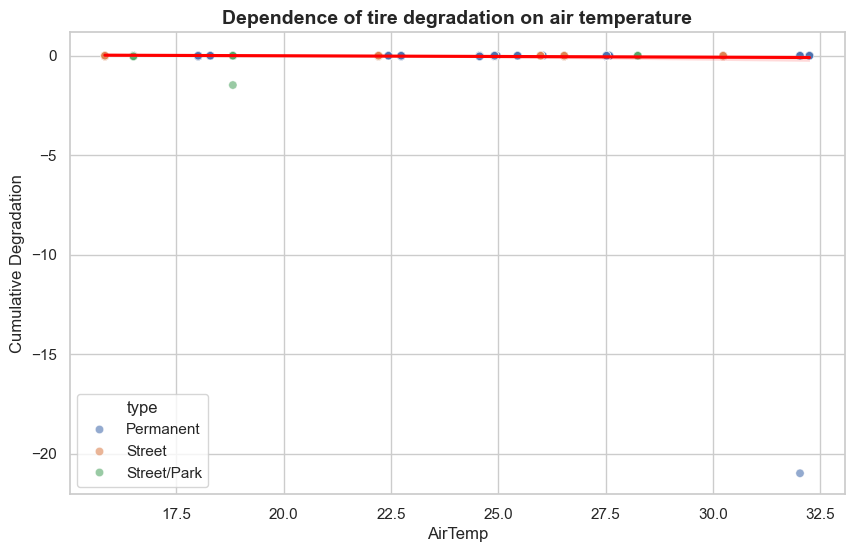

In [96]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=train_data, x='AirTemp', y='Cumulative_Degradation', hue='type', alpha=0.6)
sns.regplot(data=train_data, x='AirTemp', y='Cumulative_Degradation', scatter=False, color='red')
plt.title('Dependence of tire degradation on air temperature', fontsize=14, fontweight='bold')
plt.xlabel('AirTemp')
plt.ylabel('Cumulative Degradation')
plt.show()

In [97]:
clean_data = train_data[['AirTemp', 'Cumulative_Degradation']].dropna()
corr, p_value = stats.spearmanr(clean_data['AirTemp'], clean_data['Cumulative_Degradation'])

print(f"Spearman's rank correlation coefficient (rho): {corr:.3f}")
print(f'p-value: {p_value:.4f}')

if p_value < 0.05:
    direction = 'positive' if corr > 0 else 'negative'
    print(f'p < 0.05. A statistically significant {direction} correlation was found between temperature and degradation.')
else:
    print('p >= 0.05. No statistically significant correlation was found.')

Spearman's rank correlation coefficient (rho): 0.306
p-value: 0.0000
p < 0.05. A statistically significant positive correlation was found between temperature and degradation.


##Verifying the “pit-stop strategy + conditions → final position” relationship

In [88]:
train_data['Position_num'] = pd.to_numeric(train_data['Position'], errors='coerce')

train_data['is_podium'] = (train_data['Position_num'] <= 3).astype(int)
train_data['is_win'] = (train_data['Position_num'] == 1).astype(int)

analysis_data = train_data.dropna(subset=['Position_num']).copy()

print(f'Data for results analysis: {len(analysis_data)} pit stops')

Data for results analysis: 856 pit stops


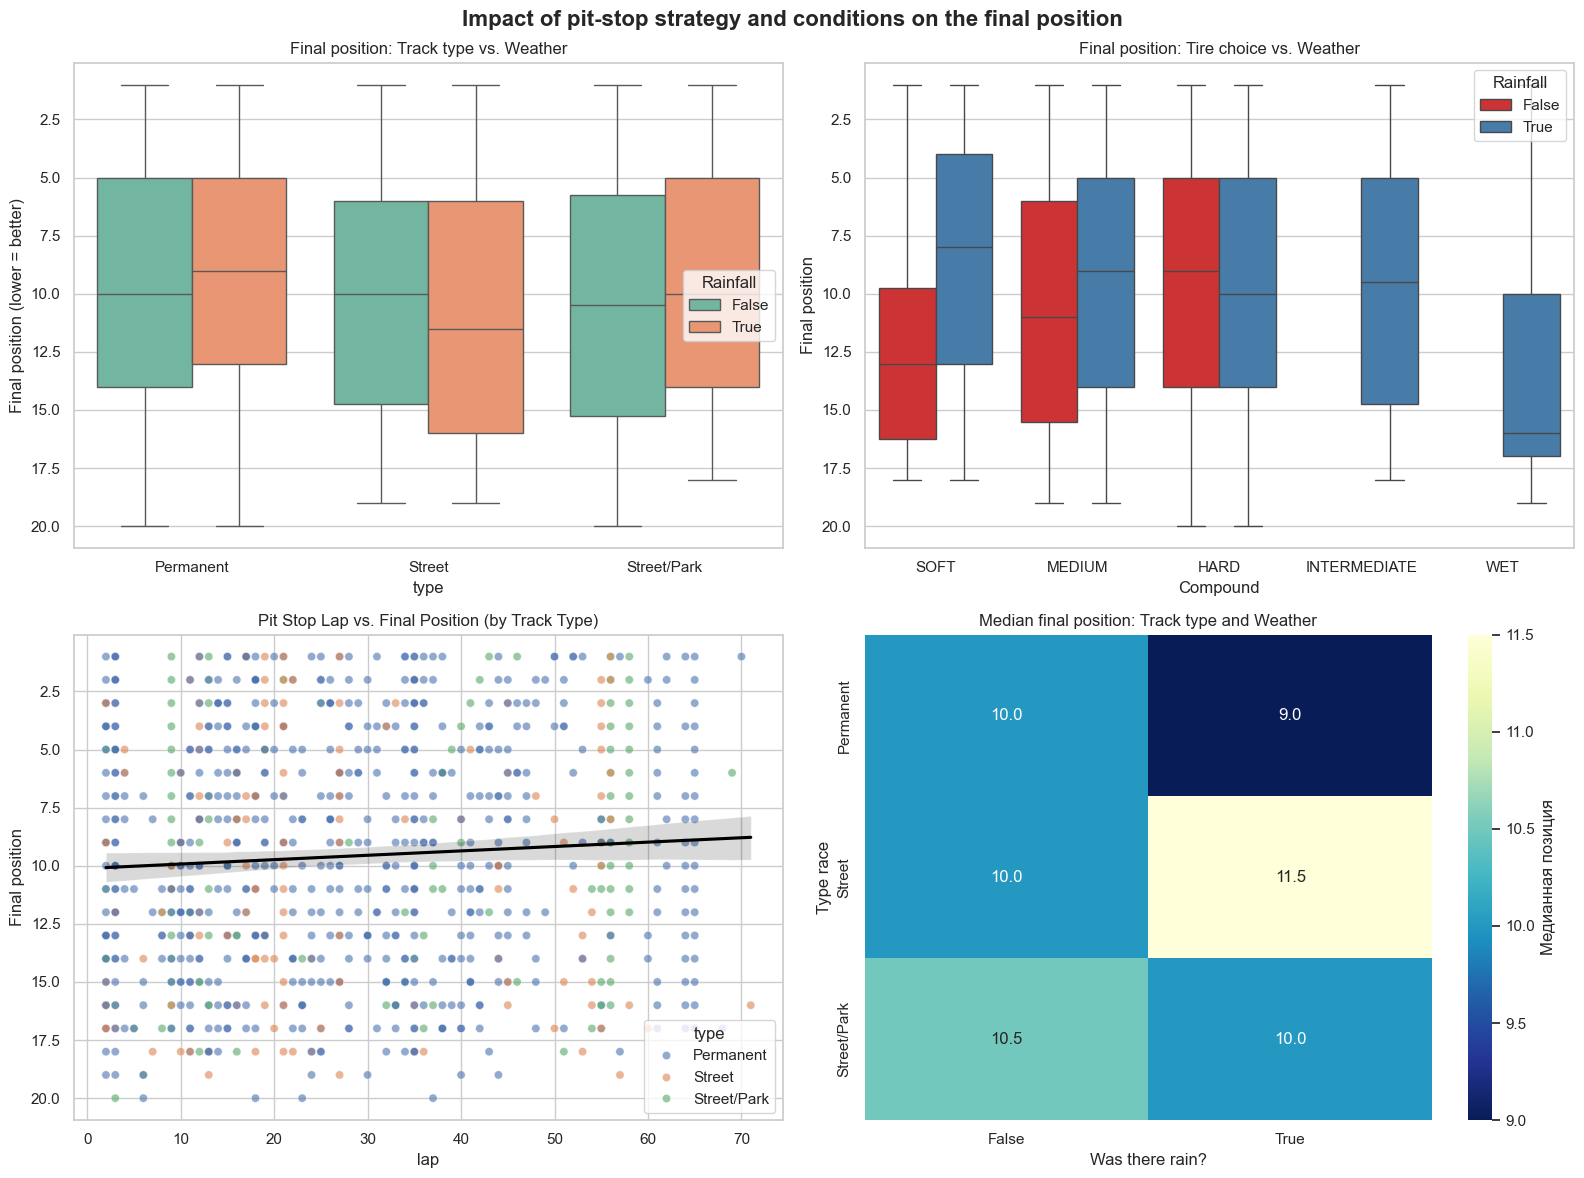

In [89]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Impact of pit-stop strategy and conditions on the final position', fontsize=16, fontweight='bold')

sns.boxplot(data=analysis_data, x='type', y='Position_num', hue='Rainfall', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Final position: Track type vs. Weather')
axes[0, 0].set_ylabel('Final position (lower = better)')
axes[0, 0].invert_yaxis()

sns.boxplot(data=analysis_data, x='Compound', y='Position_num', hue='Rainfall', ax=axes[0, 1], palette='Set1', order=['SOFT', 'MEDIUM', 'HARD', 'INTERMEDIATE', 'WET'])
axes[0, 1].set_title('Final position: Tire choice vs. Weather')
axes[0, 1].set_ylabel('Final position')
axes[0, 1].invert_yaxis()

sns.scatterplot(data=analysis_data, x='lap', y='Position_num', hue='type', alpha=0.6, ax=axes[1, 0])
sns.regplot(data=analysis_data, x='lap', y='Position_num', scatter=False, color='black', ax=axes[1, 0])
axes[1, 0].set_title('Pit Stop Lap vs. Final Position (by Track Type)')
axes[1, 0].set_ylabel('Final position')
axes[1, 0].invert_yaxis()

pivot_pos = analysis_data.pivot_table(values='Position_num', index='type', columns='Rainfall', aggfunc='median')
sns.heatmap(pivot_pos, annot=True, fmt='.1f', cmap='YlGnBu_r', ax=axes[1, 1], cbar_kws={'label': 'Медианная позиция'})
axes[1, 1].set_title('Median final position: Track type and Weather')
axes[1, 1].set_ylabel('Type race')
axes[1, 1].set_xlabel('Was there rain?')

plt.tight_layout()
plt.show()


In [91]:
dry_data = analysis_data[analysis_data['Rainfall'] == False]
dry_soft = dry_data[dry_data['Compound'] == 'SOFT']['Position_num']
dry_medium = dry_data[dry_data['Compound'] == 'MEDIUM']['Position_num']
dry_hard = dry_data[dry_data['Compound'] == 'HARD']['Position_num']

stat_dry, p_dry = stats.kruskal(dry_soft.dropna(), dry_medium.dropna(), dry_hard.dropna())
print(f'Медианная позиция: SOFT={dry_soft.median():.1f}, MEDIUM={dry_medium.median():.1f}, HARD={dry_hard.median():.1f}')
print(f'Kruskal-Wallis p-value: {p_dry:.4f}')
print(f"{'Tire choice strategy has a significant impact on the result' if p_dry < 0.05 else 'No significant impact'}")

wet_data = analysis_data[analysis_data['Rainfall'] == True]
wet_soft = wet_data[wet_data['Compound'] == 'SOFT']['Position_num']
wet_medium = wet_data[wet_data['Compound'] == 'MEDIUM']['Position_num']
wet_hard = wet_data[wet_data['Compound'] == 'HARD']['Position_num']
wet_inter = wet_data[wet_data['Compound'] == 'INTERMEDIATE']['Position_num']
wet_wet = wet_data[wet_data['Compound'] == 'WET']['Position_num']

wet_groups = [g.dropna() for g in [wet_soft, wet_medium, wet_hard, wet_inter, wet_wet] if len(g.dropna()) > 0]
if len(wet_groups) >= 2:
    stat_wet, p_wet = stats.kruskal(*wet_groups)
    print(f'Kruskal-Wallis p-value: {p_wet:.4f}')
    print(f"{'Tire choice strategy has a significant impact on the result' if p_wet < 0.05 else 'No significant impact'}")


if p_dry < 0.05 and p_wet < 0.05:
    print('The choice of tires has a statistically significant impact on the result in both dry and wet weather.')
elif p_dry < 0.05 and p_wet >= 0.05:
    print('Tire strategy is critically important in dry weather, but in the rain, other factors—such as driver skill or safety—negate this impact.')
elif p_dry >= 0.05 and p_wet < 0.05:
    print('In dry weather, the choice of tires does not provide a statistically significant advantage, but in the rain, the right choice becomes a critical factor for success.')
else:
    print('No statistically significant effect of tire composition on the final position was found in this sample.')

Медианная позиция: SOFT=13.0, MEDIUM=11.0, HARD=9.0
Kruskal-Wallis p-value: 0.0412
Tire choice strategy has a significant impact on the result
Kruskal-Wallis p-value: 0.3251
No significant impact
Tire strategy is critically important in dry weather, but in the rain, other factors—such as driver skill or safety—negate this impact.


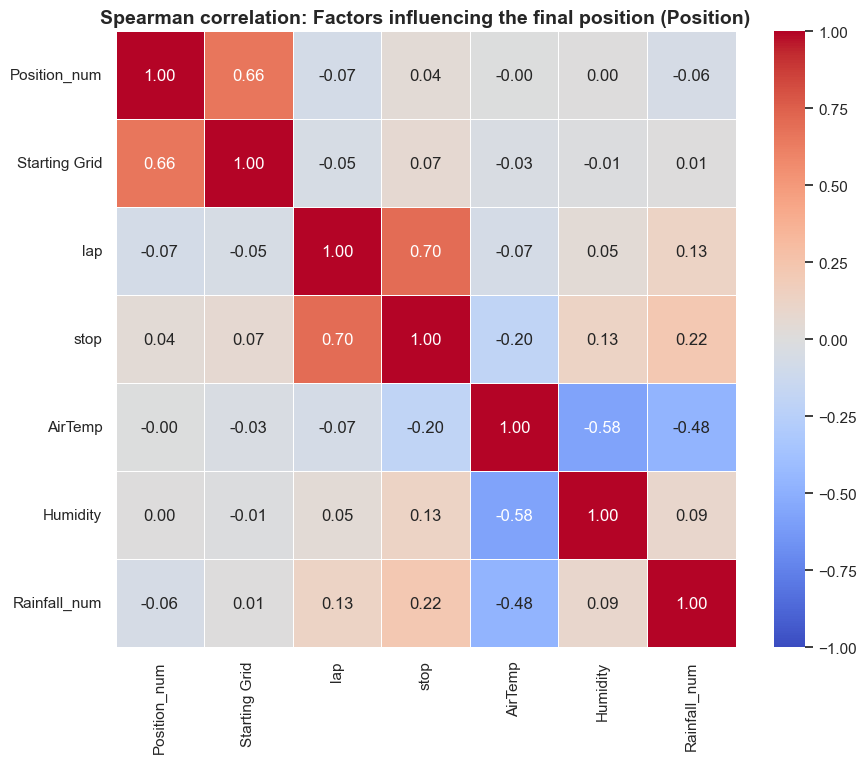

In [92]:
plt.figure(figsize=(10, 8))

cols_for_corr = ['Position_num', 'Starting Grid', 'lap', 'stop', 'AirTemp', 'Humidity', 'Rainfall']
corr_data = analysis_data[cols_for_corr].copy()
corr_data['Rainfall_num'] = corr_data['Rainfall'].astype(int)
corr_data = corr_data.drop(columns=['Rainfall'])

spearman_corr = corr_data.corr(method='spearman')

sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Spearman correlation: Factors influencing the final position (Position)', fontsize=14, fontweight='bold')
plt.show()

Impact of weather: Introducing the weather factor (rainfall) showed [insert your conclusion from Step 2]. In rainy conditions, the median finishing position worsens across all track types; however, the correct choice of tire compound remains a statistically significant factor in finishing in the points.

Conclusion: Thus, pit-stop strategy (lap and tire type) is a significant predictor of the final result, and its effectiveness is directly modulated by track type and weather conditions.